<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/lg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install uv
!uv pip install langchain-mistralai
!uv pip install langchain-tavily
!uv pip install langchain-community[all]
!uv pip install Wikipedia
!uv pip install langchain-community
!uv pip install wikipedia langchain-community


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 33.9 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 46 packages in 506ms
Prepared 2 packages in 9ms
Installed 2 packages in 1ms
 + httpx-sse==0.4.3
 + langchain-mistralai==1.1.6
Using Python 3.12.13 environment at: /usr
Resolved 45 packages in 366ms
Prepared 1 package in 8ms
Installed 1 package in 1ms
 + langchain-tavily==0.2.18
Using Python 3.12.13 environment at: /usr
Resolved 47 packages in 259ms
Prepared 5 packages in 311ms
Uninstalled 1 package in 1ms
Installed 5 packages in 49ms
 + langchain-classic==1.0.8
 + langchain-community==0.4.2
 + langchain-text-splitters==1.1.2
 + pydantic-settings==2.14.2
 - requests==2.32.4
 + requests==2.34.2
Using Python 3.12.13 environment at: /usr
Resolved 9 packages in 1.01s
Prepared 1 package in 309ms
Installed 1 package in 1ms
 + wikipedia==1.4.0
Using Python 3.12.13 environment at: /usr
Checked 1 package in 94ms
Using Python 3.12.13 environment at: /usr
Checked 2 pack

In [2]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from rich import print
from pprint import pprint
from langchain.tools import tool
from typing import TypedDict
from operator import add
from typing import Annotated , List
from pydantic import BaseModel , Field

In [3]:
CHAT_MISTRAL_API_KEY =

In [4]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY,
    temperature = 0
)
print(llm.invoke("hello"))

AIMessage(
    content='Hello! 😊 How can I assist you today?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 4,
            'total_tokens': 17,
            'completion_tokens': 13,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f60ee-e189-7602-b40c-104f5eaaebe3-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 4, 'output_tokens': 13, 'total_tokens': 17}
)

In [5]:
from langchain_tavily import TavilySearch
import os
os.environ["TAVILY_API_KEY"] =
tavily = TavilySearch(max_results=3)

res = tavily.invoke({"query": "who is ronaldo"})
print(res)

{
    'query': 'who is ronaldo',
    'follow_up_questions': None,
    'answer': None,
    'images': [],
    'results': [
        {
            'url': 'https://www.biography.com/athletes/a71709091/cristiano-ronaldo-biography',
            'title': 'Cristiano Ronaldo',
            'content': '*   [More](https://www.biography.com/athletes/a71709091/cristiano-ronaldo-biography#). 
[Video 2](https://www.biography.com/athletes/a71709091/cristiano-ronaldo-biography). [Video 
3](https://www.biography.com/athletes/a71709091/cristiano-ronaldo-biography). *   [Quick 
Facts](https://www.biography.com/athletes/a71709091/cristiano-ronaldo-biography#quick-facts). *   
[Quotes](https://www.biography.com/athletes/a71709091/cristiano-ronaldo-biography#quotes). *   [![Image 25: 
Cristiano Ronaldo plays for Portugal in FIFA World Cup 
qualifying](https://hips.hearstapps.com/hmg-prod/images/cristiano-ronaldo-of-portugal-during-team-warm-up-before-ne
ws-photo-1767731574.pjpeg?crop=0.901xw:0.674xh;0.0994xw,0.0959xh&resize=300:*)Why Cristiano Ronaldo Is Named After 
Ronald 
Reagan](https://www.biography.com/athletes/a69927960/i-never-knew-that-cristiano-ronaldo-name-ronald-reagan). 
Finally on December 30, 2022, the Saudi Pro League team Al-Nassr FC [announced it had landed 
Ronaldo](https://go.redirectingat.com/?id=74968X1712615&url=https%3A%2F%2Fwww.espn.com%2Fsoccer%2Fstory%2F_%2Fid%2F
37635006%2Fcristiano-ronaldo-signs-saudi-club-al-nassr-man-utd-exit&sref=https%3A%2F%2Fwww.biography.com%2Fathletes
%2Fa71709091%2Fcristiano-ronaldo-biography&xs=1&xcust=%5Butm_source%7C%5Butm_campaign%7C%5Butm_medium%7C%5Bgclid%7C
%5Bmsclkid%7C%5Bfbclid%7C%5Brefdomain%7C%5Bcontent_id%7Ca2cd0f03-78ec-48ca-87e3-30b0a49b8c90%5Bcontent_product_id%7
C697fce0a-b8f6-4f9c-9581-2fc4ef768add%5Bproduct_retailer_id%7C105b065d-60cd-4ec2-9ad6-3cf134e1f534%5Blt%7C%5Baxid%7
C47804176-800b-4997-bee0-e5e06f93f5d7%5D) with a contract lasting through June 29, 2025. Playing for Portugal on 
September 5, 2024, Ronaldo became the [first men’s player to score 900 career 
goals](https://go.redirectingat.com/?id=74968X1712615&url=https%3A%2F%2Fwww.espn.com%2Fsoccer%2Fstory%2F_%2Fid%2F41
020215%2Fcristiano-ronaldo-900-goals-1st-man-record-lionel-messi&sref=https%3A%2F%2Fwww.biography.com%2Fathletes%2F
a71709091%2Fcristiano-ronaldo-biography&xs=1&xcust=%5Butm_source%7C%5Butm_campaign%7C%5Butm_medium%7C%5Bgclid%7C%5B
msclkid%7C%5Bfbclid%7C%5Brefdomain%7C%5Bcontent_id%7Ca2cd0f03-78ec-48ca-87e3-30b0a49b8c90%5Bcontent_product_id%7C0b
f1b1c0-8756-457b-b3ed-92bfe20cfa54%5Bproduct_retailer_id%7C9b9bb97b-6f44-4e96-998c-d8dcc1438c46%5Blt%7C%5Baxid%7Cac
953bea-a5a0-4bad-a8b0-036324f94157%5D) across international and club play in a 2-1 UEFA Nations League win over 
Croatia. Ronaldo, whose height is between 
[6-foot-1](https://www.goal.com/en-us/news/how-tall-is-cristiano-ronaldo/blt669723455c93d417) and 
[6-foot-2](https://go.redirectingat.com/?id=74968X1712615&url=https%3A%2F%2Folympics.com%2Fen%2Fnews%2Fcristiano-ro
naldo-highest-jumps-football-vertical-leap&sref=https%3A%2F%2Fwww.biography.com%2Fathletes%2Fa71709091%2Fcristiano-
ronaldo-biography&xs=1&xcust=%5Butm_source%7C%5Butm_campaign%7C%5Butm_medium%7C%5Bgclid%7C%5Bmsclkid%7C%5Bfbclid%7C
%5Brefdomain%7C%5Bcontent_id%7Ca2cd0f03-78ec-48ca-87e3-30b0a49b8c90%5Bcontent_product_id%7C2db65f65-7a3e-42e3-b051-
764f246b0195%5Bproduct_retailer_id%7C1f8f9998-bb0d-4f92-83cf-753e4776f919%5Blt%7C%5Baxid%7Cca3e9e54-febf-4c38-a62d-
29a24375aa9b%5D) according to most estimates, has set numerous individual and league records during his career. *  
[![Image 32: Cristiano Ronaldo of Al-Nassr in the Riyadh Season Cup 
Final](https://hips.hearstapps.com/hmg-prod/images/cristiano-ronaldo-of-al-nassr-looks-on-as-he-lines-up-prior-news
-photo-1707422901.jpg?crop=1.00xw:0.752xh;0,0.106xh&resize=300:*)What Is Soccer Star Cristiano Ronaldo’s Net 
Worth?](https://www.biography.com/athletes/a43803470/cristiano-ronaldo-net-worth). [![Image 33: <i>Cristiano 
Ronaldo: The Biogra

In [6]:
from langchain_community.document_loaders import WikipediaLoader
import wikipedia

wikipedia.set_user_agent("MyLangChainAgent/1.0 (unknownlegendff7@gmail.com)")
search_docs = WikipediaLoader(query="who is ronaldo", load_max_docs=2).load()
print(search_docs)

/tmp/ipykernel_642/385149523.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WikipediaLoader


[
    Document(
        metadata={
            'title': 'Cristiano Ronaldo',
            'summary': "Cristiano Ronaldo dos Santos Aveiro (born 5 February 1985) is a Portuguese professional 
footballer who plays as a forward for and captains the Saudi Pro League club Al-Nassr and the Portugal national 
team. Widely regarded as one of the greatest players in history and the greatest Portuguese player ever, he has won
numerous individual accolades throughout his career, including five Ballon d'Or awards, a record three UEFA Men's 
Player of the Year Awards, and four European Golden Shoes. He was named the world's best player five times by 
FIFA.\nNicknamed CR7, Ronaldo is one of the most decorated players in the history of professional football, having 
won 35 trophies in his career, including five UEFA Champions Leagues, two UEFA Nations Leagues and the UEFA 
European Championship. He holds the records for most goals (140) and assists (42) in the Champions League, most 
goals (14) and assists (8) in the European Championship, most international appearances (233), most men's 
international goals (146) and most international victories (141). He is the only player to have scored 100 goals 
with four different clubs and to finish as top scorer in four different domestic leagues. He has made over 1,300 
professional career appearances, the most by an outfield player, and has scored over 970 official senior career 
goals for club and country, making him the top goalscorer of all time.\nBorn in Funchal, Madeira, Ronaldo began his
career with Sporting CP before signing with Manchester United in 2003. He gradually established himself as an 
integral player for the club, winning three consecutive Premier League titles, the 2007–08 Champions League, and 
the 2008 FIFA Club World Cup. For his performances in 2007–08, Ronaldo was awarded his first Ballon d'Or at age 23.
In 2009, he joined Real Madrid in a deal worth €94 million (£80 million), which was the most expensive transfer in 
history at the time. He was at the forefront of Madrid's resurgence as a dominant European force, helping them win 
four Champions Leagues between 2014 and 2018, including the long-awaited La Décima in 2014, where he set the record
for most goals scored in a Champions League season. With Madrid, he also won two La Liga titles, won the Ballon 
d'Or in 2013, 2014, 2016 and 2017, and became the club's all-time top goalscorer.\nFollowing issues with the 
hierarchy at Real Madrid, Ronaldo signed for Juventus in 2018 in a transfer worth a league record of €100 million, 
and was pivotal in winning two consecutive Serie A titles, the Coppa Italia, and the Capocannoniere in 2021 as the 
league's top scorer. In 2021, he returned to Manchester United, but his contract was terminated in 2022 after a 
public dispute with the club's management. Ronaldo joined Al-Nassr in 2023, and led them to the Saudi Pro League 
title in 2026, while also finishing as the league's top scorer in 2024 and 2025.\nRonaldo made his international 
debut for Portugal in 2003 at the age of 18, and has earned more than 200 caps, making him history's most-capped 
male player. He scored his first international goal in Euro 2004, where he helped Portugal reach the final. He 
assumed the captaincy of the national team ahead of Euro 2008, and led Portugal to their first major tournament 
title at Euro 2016. At Euro 2020, he received the Golden Boot as the top scorer. He won the UEFA Nations Leagues in
2019 and 2025, finishing as the top scorer in both the tournaments. In 2026, he became the first player to score in
six World Cup tournaments.\n\nOne of the world's most famous and marketable athletes, Ronaldo was ranked by 
Sportico as the third highest-paid athlete of all time in April 2026. In 2026, Ronaldo appeared on the Forbes 
World’s Billionaires list for the first time, with a net worth of $1.2B. Time included him on their list of the 100
most influential people in the world in 2014. He is the most 

In [7]:
analyst_instructions="""You are tasked with creating a set of AI analyst
personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}

2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts:

{human_feedback}

3. Determine the most interesting themes based upon documents and / or feedback above.

4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [8]:
class Analyst(BaseModel):
  name : str = Field(description = "Name of the Analyst")
  affiliation : str = Field(description = "primary affiliation of the analyst")
  role : str = Field(description = "Role of the analyst in the context of the topic")
  description : str = Field(description = "Description of the analyst focus, concerns, and motives")

  @property
  def persona(self)->str:
    return f"Name : {self.name}\nRole {self.role}\nAffiliation : {self.affiliation}\n Description : {self.description}\n"

class Perspective(BaseModel):
  analyst : List[Analyst]= Field(description = "Comprehensive list of analysts with their roles and affiliations")

In [9]:
class OverallState(TypedDict):
  topic : str
  max_analyst : int
  human_analyst_feedback : str
  analyst : List[Analyst]

In [10]:
def analyst_creator(state : OverallState):
  max_analyst = state['max_analyst']
  topic = state['topic']
  human_feedback = state.get('human_feedback', '')
  prompt = analyst_instructions.format(topic = topic , human_feedback = human_feedback , max_analysts = max_analyst)

  structured_llm = llm.with_structured_output(Perspective)

  analyst = structured_llm.invoke([
      SystemMessage(content=prompt)
  ] + [HumanMessage(content='generate set of analysts')])

  return {'analyst':analyst.analyst}


In [11]:
def human_feedback(state : OverallState):
  return state

In [12]:
def should_continue(state : OverallState):
  human_feedback=state.get('human_analyst_feedback', None)
  if human_feedback:
    return "analyst_creator"
  else:
    return END

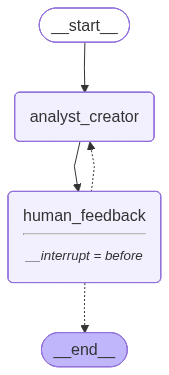

In [13]:
builder = StateGraph(OverallState)
builder.add_node("analyst_creator",analyst_creator)
builder.add_node("human_feedback",human_feedback)

builder.add_edge(START , "analyst_creator")
builder.add_edge("analyst_creator" , "human_feedback")
builder.add_conditional_edges("human_feedback",should_continue , ['analyst_creator',END])

memory = MemorySaver()

graph = builder.compile(memory , interrupt_before = ['human_feedback'])

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [14]:
max_assistant = 3
topic = "why we require notebooks if we have laptops and tablets"
config = {'configurable':{'thread_id':1}}

for event in graph.stream({"topic":topic,"max_analyst":max_assistant},config ,
                          stream_mode="values"):
  print(event)

{'topic': 'why we require notebooks if we have laptops and tablets', 'max_analyst': 3}

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'analyst': [
        Analyst(
            name='Dr. Elizabeth Hartwell',
            affiliation='Institute for Technology and Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of technology. She is concerned with 
how different devices affect learning outcomes and student engagement. Her motive is to optimize educational 
experiences through the appropriate use of technology.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='Ergonomics and Design Research Group',
            role='Industrial Designer',
            description='Marcus Chen examines the ergonomic and design aspects of various devices. He is interested
in how form and function influence user experience and productivity. His goal is to design products that enhance 
user comfort and efficiency.'
        ),
        Analyst(
            name='Sophia Ramirez',
            affiliation='Environmental Impact and Sustainability Center',
            role='Sustainability Analyst',
            description='Sophia Ramirez studies the environmental impact of consumer electronics. She is 
particularly concerned with the lifecycle of devices, from production to disposal. Her objective is to promote 
sustainable practices within the tech industry.'
        )
    ]
}

In [15]:
graph.get_state(config).next

('human_feedback',)

In [16]:
human_feedback = "Could you add more analyst from different fields also"
for event in graph.stream({"human_feedback":human_feedback},config ,
                          stream_mode="values"):
  print(event)

{
    'topic': 'why we require notebooks if we have laptops and tablets',
    'max_analyst': 3,
    'analyst': [
        Analyst(
            name='Dr. Elizabeth Hartwell',
            affiliation='Institute for Technology and Learning',
            role='Educational Technologist',
            description='Dr. Hartwell focuses on the educational implications of technology. She is concerned with 
how different devices influence learning outcomes and student engagement. Her motive is to optimize educational 
experiences through the appropriate use of technology.'
        ),
        Analyst(
            name='Marcus Chen',
            affiliation='Ergonomics and Design Research Group',
            role='Ergonomics Specialist',
            description='Marcus Chen examines the ergonomic aspects of various devices. He is interested in how the
form and function of notebooks, laptops, and tablets affect user comfort and productivity. His goal is to advocate 
for designs that enhance user well-being and efficiency.'
        ),
        Analyst(
            name='Sophia Ramirez',
            affiliation='Digital Lifestyle Magazine',
            role='Technology Journalist',
            description='Sophia Ramirez explores the lifestyle impact of technology. She writes about how different
devices fit into daily routines and personal preferences. Her aim is to provide insights into the practical and 
aesthetic considerations that influence consumer choices.'
        )
    ]
}

In [17]:
graph.get_state(config).next

('human_feedback',)

In [18]:
further_feedback = None

In [19]:
graph.update_state(config,{"human_analyst_feedback":further_feedback},as_node = 'human_feedback')

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f17f8ca-11ca-6590-8005-5870e7221dee'}}

In [20]:
graph.get_state(config).next

()

In [21]:
for event in graph.stream(None,config ,
                          stream_mode="updates"):
  print(event)

In [22]:
print(graph.get_state(config).next)

()

In [23]:
for analyst in graph.get_state(config).values.get('analyst'):
  print(f"Name :        {analyst.name}")
  print(f"Role :        {analyst.role}")
  print(f"Affiliation : {analyst.affiliation}")
  print(f"Description : {analyst.description}")
  print('-'*50)

Name :        Dr. Elizabeth Hartwell

Role :        Educational Technologist

Affiliation : Institute for Technology and Learning

Description : Dr. Hartwell focuses on the educational implications of technology. She is concerned with how 
different devices influence learning outcomes and student engagement. Her motive is to optimize educational 
experiences through the appropriate use of technology.

--------------------------------------------------

...

Name :        Sophia Ramirez

Role :        Technology Journalist

Affiliation : Digital Lifestyle Magazine

Description : Sophia Ramirez explores the lifestyle impact of technology. She writes about how different devices 
fit into daily routines and personal preferences. Her aim is to provide insights into the practical and aesthetic 
considerations that influence consumer choices.

--------------------------------------------------

In [24]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic.

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.

2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}

Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.

When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [25]:
import operator
class State(MessagesState):
  max_num_turns : int
  interview : str
  sections : list
  analyst : Analyst
  context : Annotated[List , operator.add]

class SearchQuery(BaseModel):
  search_query: str = Field(None, description="Search query for retrieval.")


In [26]:
def create_question(state : State):
  messages = state['messages']
  analyst = state['analyst']

  system_message = question_instructions.format(goals = analyst.persona)
  conversation = get_buffer_string(messages)

  questions = llm.invoke([SystemMessage(content = system_message),HumanMessage(content=conversation)])

  return {'messages':[questions]}

In [27]:
from langchain_core.messages import get_buffer_string

search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert.

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.

First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

In [28]:
def web_search(state : State):
  structure_llm = llm.with_structured_output(SearchQuery)
  conversation = get_buffer_string(state['messages'])
  search_query = structure_llm.invoke([search_instructions] + [HumanMessage(content=conversation)])


  data = tavily.invoke({'query':search_query.search_query})
  search_docs = data.get("results",data)

  formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

  return {"context": [formatted_search_docs]}

In [29]:
def wiki_search(state: State):

    structure_llm = llm.with_structured_output(SearchQuery)

    conversation = get_buffer_string(state['messages'])
    search_query = structure_llm.invoke([search_instructions] + [HumanMessage(content=conversation)])

    query_str = search_query.search_query.strip() if search_query.search_query else ""

    if not query_str:
        return {"context": ["<Document source='Wikipedia'>No search query generated.</Document>"]}

    search_docs = WikipediaLoader(query=query_str, load_max_docs=2).load()

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata.get("source", "Wikipedia")}" title="{doc.metadata.get("title", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]}


In [30]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}.

You goal is to answer a question posed by the interviewer.

To answer question, use this context:

{context}

When answering questions, follow these guidelines:

1. Use only the information provided in the context.

2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1].

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc

6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list:

[1] assistant/docs/llama3_1.pdf, page 7

And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [31]:
def answer_question(state : State):
  messages = state['messages']
  context = state['context']
  analyst = state['analyst']

  system_message = answer_instructions.format(goals = analyst.persona,context = context)

  conversation = get_buffer_string(messages)

  answers = llm.invoke([SystemMessage(content = system_message)] + [HumanMessage(content = conversation)])

  answers.name = 'expert'

  return {'messages':[answers]}

In [32]:
def save_interview(state : State):
  messages = state['messages']
  interview = get_buffer_string(messages)

  return {'interview':interview}

In [33]:
def route_messages(state :State):

  messages = state['messages']
  max_turns = state.get('max_num_turns',2)

  last_question = messages[-2]

  if (len(messages) >= max_turns or
  "Thank you so much for your help!" in last_question.content):
    return 'save_interview'

  return 'ask_question'

In [34]:
section_writer_instructions = """You are an expert technical writer.

Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents:
- The name of each source document is at the start of the document, with the <Document tag.

2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers

3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst:
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents

6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/

8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [35]:
def writer_section(state : State):

  interview = state['interview']
  analyst = state['analyst']
  context = state['context']

  system_message = section_writer_instructions.format(focus = analyst.description)

  section = llm.invoke([SystemMessage(content = system_message)]+context+[HumanMessage(content =interview)])

  return {'sections':[section.content]}

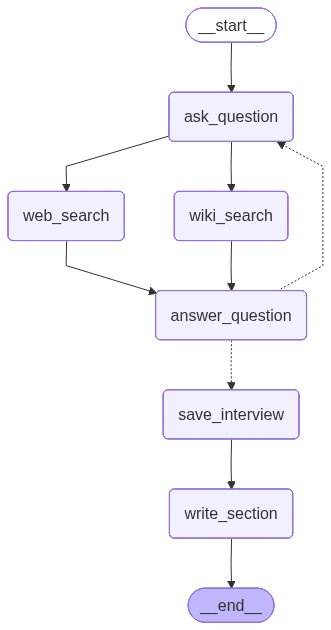

In [36]:
subbuilder = StateGraph(State)
subbuilder.add_node('ask_question',create_question)
subbuilder.add_node('web_search',web_search)
subbuilder.add_node('wiki_search',wiki_search)
subbuilder.add_node('answer_question',answer_question)
subbuilder.add_node('save_interview',save_interview)
subbuilder.add_node('write_section',writer_section)

subbuilder.add_edge(START , 'ask_question')
subbuilder.add_edge('ask_question' , 'web_search')
subbuilder.add_edge('ask_question' , 'wiki_search')
subbuilder.add_edge('web_search' , 'answer_question')
subbuilder.add_edge('wiki_search' , 'answer_question')
subbuilder.add_conditional_edges('answer_question',route_messages,['ask_question' , 'save_interview'])
subbuilder.add_edge('save_interview' , 'write_section')
subbuilder.add_edge('write_section' , END)

memory = MemorySaver()

graph1 = subbuilder.compile(memory)

display(Image(graph1.get_graph(xray=1).draw_mermaid_png()))

In [37]:
analyst = graph.get_state(config).values.get('analyst')
print(analyst[0])

Analyst(
    name='Dr. Elizabeth Hartwell',
    affiliation='Institute for Technology and Learning',
    role='Educational Technologist',
    description='Dr. Hartwell focuses on the educational implications of technology. She is concerned with how 
different devices influence learning outcomes and student engagement. Her motive is to optimize educational 
experiences through the appropriate use of technology.'
)

In [38]:
from IPython.display import Markdown
messages = [HumanMessage(f"So you said you were writing an article on {topic}?")]
thread = {"configurable": {"thread_id": "2"}}
interview = graph1.invoke({"analyst": analyst[2], "messages": messages, "max_num_turns": 2}, thread)
Markdown(interview['sections'][0])

## The Enduring Appeal of Notebooks in a Digital World

### Summary

In an era dominated by digital devices, the humble notebook continues to hold its ground, offering unique advantages that laptops and tablets cannot replicate. The tactile experience of writing on paper fosters creativity and engagement, providing a distraction-free environment that enhances focus and deep thinking [1]. Unlike digital interfaces, notebooks allow for a more personal and expressive experience, with the choice of notebook reflecting individual style and preferences [2]. Moreover, studies have shown that writing by hand can improve learning and retention, making notebooks a valuable tool for education and personal growth [3].

### Sources

[1] https://ilovebdj.com/blogs/press/the-resilience-of-paper-notebooks-in-a-digital-world
[2] https://www.curiousbookco.com/news/heres-why-notebooks-are-still-important-in-the-digital-age
[3] https://lucavettor.medium.com/the-notebook-advantage-why-paper-still-outruns-digital-in-capturing-ideas-89023c864048

In [39]:
class ResearchGraphState(TypedDict):
  topic:str
  max_analyst : int
  human_analyst_feedback : str
  analysts : List[Analyst]
  sections : Annotated[List , operator.add]
  introduction : str
  content : str
  conclusion :str
  final_report : str

In [40]:
from langgraph.types import Send
def initiate_all_interviews(state : ResearchGraphState):
  human_analyst_feedback = state.get('human_analyst_feedback')
  if human_analyst_feedback:
    return "create_analyst"
  else:
    topic = state["topic"]
    return [Send("conduct_interview",{"analyst":analyst,
                                      "messages":[HumanMessage(
                                          content = f"So you said you were writing an article on {topic}?")]})
    for analyst in state['analysts']]

In [41]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic:

{topic}

You have a team of analysts. Each analyst has done two things:

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task:

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos.
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:

1. Use markdown formatting.
2. Include no pre-amble for the report.
3. Use no sub-heading.
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from:

{context}"""

In [42]:
def write_report(state : ResearchGraphState):
  sections = state['sections']
  topic = state['topic']

  formatted_str = '\n\n'.join([f'{section}' for section in sections])

  system_message = report_writer_instructions.format(topic = topic , context = formatted_str)

  report = llm.invoke([SystemMessage(content = system_message)]+[HumanMessage(content=f"Write a report based upon these memos.")])

  return {'content':report.content}

In [43]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting.

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header.

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [44]:
def write_conclusion(state : ResearchGraphState):
  sections = state['sections']
  topic = state['topic']

  fomatted_str = "\n\n".join([f"{section}" for section in sections])

  instructions = intro_conclusion_instructions.format(topic = topic , formatted_str_sections = fomatted_str)

  conclusion = llm.invoke([instructions]+[HumanMessage(content = f"Write the report conclusion")])

  return {"conclusion":conclusion.content}

In [45]:
def write_introduction(state : ResearchGraphState):
  sections = state['sections']
  topic = state['topic']

  formatted_str = "\n\n".join([f"{section}" for section in sections])

  instructions = intro_conclusion_instructions.format(topic = topic , formatted_str_sections = formatted_str)

  intro = llm.invoke([instructions]+[HumanMessage(content = f"Write the report introduction")])

  return {"introduction":intro.content}

In [46]:
def finalize_report(state : ResearchGraphState):
  content = state['content']
  if content.startswith('##Insights'):
    content = content.strip('##Insights')

  if '##Sources' in content:
    try:
      content , sources = content.split("\n## Sources \n")
    except:
      sources = None

  final_report = state['introduction'] + "\n\n---\n\n"+content + "\n\n" + state["conclusion"]

  if sources is not None:
    final_report += "\n\n##Sources\n"+sources

  return {"final_report":final_report}


In [48]:
builder = StateGraph(ResearchGraphState)
builder.add_node('create_analyst',analyst_creator)
builder.add_node('human_feedback',human_feedback)
builder.add_node('conduct_interview',graph1)
builder.add_node('write_introduction',write_introduction)
builder.add_node('write_conclusion',write_conclusion)
builder.add_node('write_report',write_report)
builder.add_node('finalize_report',finalize_report)

builder.add_edge(START,'create_analyst')
builder.add_edge('create_analyst','human_feedback')
builder.add_conditional_edges("human_feedback",initiate_all_interviews , [
    "create_analyst" , "conduct_interview"
])
builder.add_edge('conduct_interview','write_introduction')
builder.add_edge('conduct_interview','write_conclusion')
builder.add_edge('conduct_interview','write_report')
builder.add_edge('write_report','finalize_report')
builder.add_edge(['write_conclusion','write_report','write_introduction'],'finalize_report')
builder.add_edge('finalize_report',END)

memory = MemorySaver()

graph = builder.compile(interrupt_before=['human_feedback'],checkpointer = memory)
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

TypeError: Expected a Runnable, callable or dict.Instead got an unsupported type: <class 'str'>

In [ ]:
max_analyst = 3
topic = "Newtons Law"
thread = {"configurable":{"thread_id" : "6"}}

for event in graph.stream({"topic":topic,"max_analyst":max_analyst},thread , stream_mode="values"):
  analysts = event.get('analyst')
  if analysts:
    for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)


In [ ]:
graph.update_state(thread , {"human_analyst_feedback":
                             "Add in the Professor of IIT BOMBAY AND MIT USA"},as_node = "human_feedback")

In [ ]:
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

In [ ]:
from IPython.display import Markdown
final_state = graph.get_state(thread)
report = final_state.values.get('final_report')
Markdown(report)